<a href="https://colab.research.google.com/github/Tolureis/CMPE-403-Fundamentals-of-Image-Processing/blob/main/Image_Compression_Opencv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Compression with OpenCV



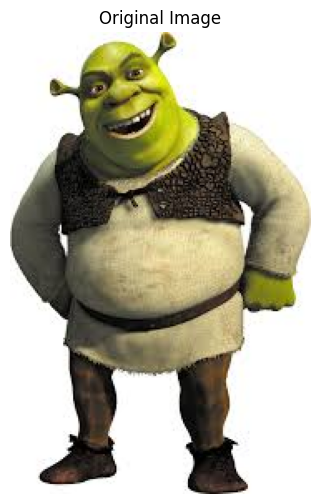

In [1]:
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Image path (enter the path to your own image file)
image_path = '/content/shrek.jpg'  # Example: 'images/example.jpg'

# Load the image
img = cv2.imread(image_path, cv2.IMREAD_COLOR)

# If the file is not found, generate a random image
if img is None:
    print('File not found, generating a random image.')
    img = np.random.randint(0, 256, (512, 512, 3), dtype=np.uint8)

# Convert from BGR to RGB (for Matplotlib)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')
plt.show()

## Compression and quality measurement functions

This section defines helper functions to compress an image and read back the compressed image in JPEG, PNG and WEBP formats. It also includes functions to calculate the **Mean Squared Error (MSE)** and **Peak Signal-to-Noise Ratio (PSNR)** to evaluate compression quality.


In [2]:
# JPEG compression (quality parameter ranges from 0-100; higher value for higher quality)
def compress_jpeg(image, quality=50):
    params = [int(cv2.IMWRITE_JPEG_QUALITY), int(quality)]
    result, enc = cv2.imencode('.jpg', image, params)
    if not result:
        raise ValueError('JPEG compression failed.')
    dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return enc, dec

# PNG compression (compression level ranges from 0-9; higher value for more compression)
def compress_png(image, compression_level=9):
    params = [int(cv2.IMWRITE_PNG_COMPRESSION), int(compression_level)]
    result, enc = cv2.imencode('.png', image, params)
    if not result:
        raise ValueError('PNG compression failed.')
    dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return enc, dec

# WEBP compression (quality parameter ranges from 1-100; 100: high quality)
def compress_webp(image, quality=80):
    params = [int(cv2.IMWRITE_WEBP_QUALITY), int(quality)]
    result, enc = cv2.imencode('.webp', image, params)
    if not result:
        raise ValueError('WEBP compression failed.')
    dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return enc, dec

# Mean Squared Error
def calculate_mse(img1, img2):
    return np.mean((img1.astype('float') - img2.astype('float')) ** 2)

# PSNR calculation
def calculate_psnr(img1, img2):
    mse = calculate_mse(img1, img2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    return 20 * np.log10(max_pixel / np.sqrt(mse))

## JPEG compression application

In this cell we will compress the image at different JPEG quality levels. As the quality parameter increases, the file size increases and the image quality improves; as the parameter decreases, the file size shrinks and the image shows more artifacts.


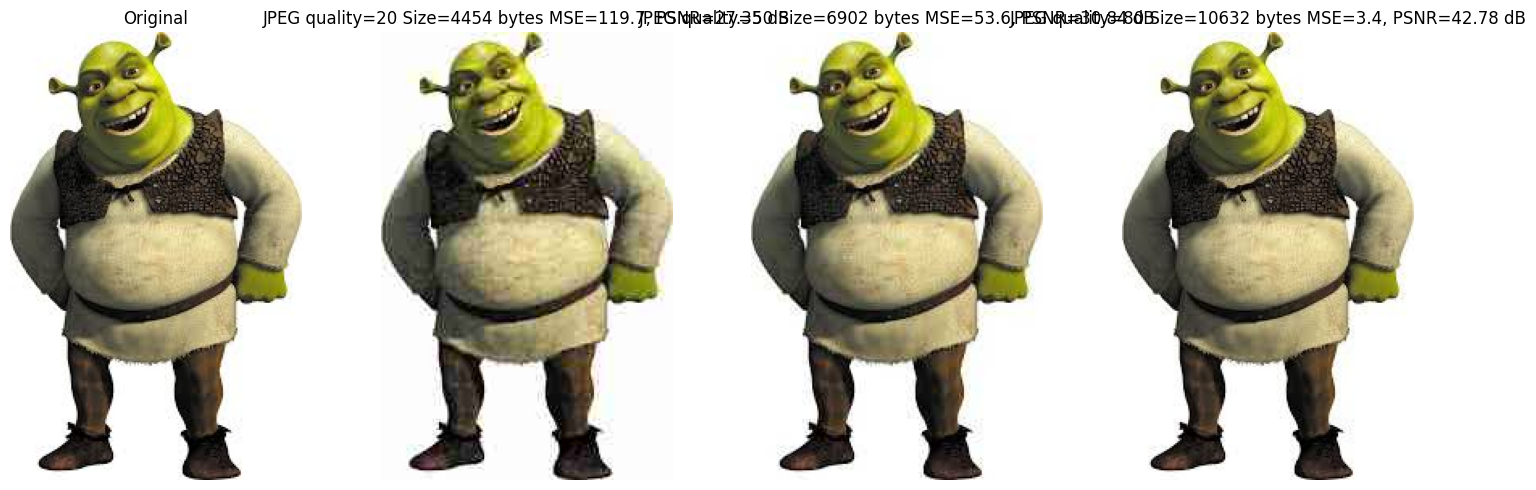

In [3]:
# JPEG compression qualities
jpeg_qualities = [20, 50, 80]

jpeg_results = []

for q in jpeg_qualities:
    enc, dec = compress_jpeg(img, quality=q)
    compressed_size = len(enc)
    original_size = img.nbytes  # original memory size (approximate)
    mse = calculate_mse(img, dec)
    psnr = calculate_psnr(img, dec)
    jpeg_results.append((q, compressed_size, mse, psnr, dec))

# Visualize the results
fig, axes = plt.subplots(1, len(jpeg_qualities) + 1, figsize=(15, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

for idx, (q, size, mse, psnr, dec_img) in enumerate(jpeg_results, 1):
    axes[idx].imshow(cv2.cvtColor(dec_img, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f'JPEG quality={q} Size={size} bytes MSE={mse:.1f}, PSNR={psnr:.2f} dB')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## PNG compression application

The PNG format is lossless; therefore there is no quality degradation. The compression level ranges from 0–9; higher levels yield smaller file sizes and slower compression.


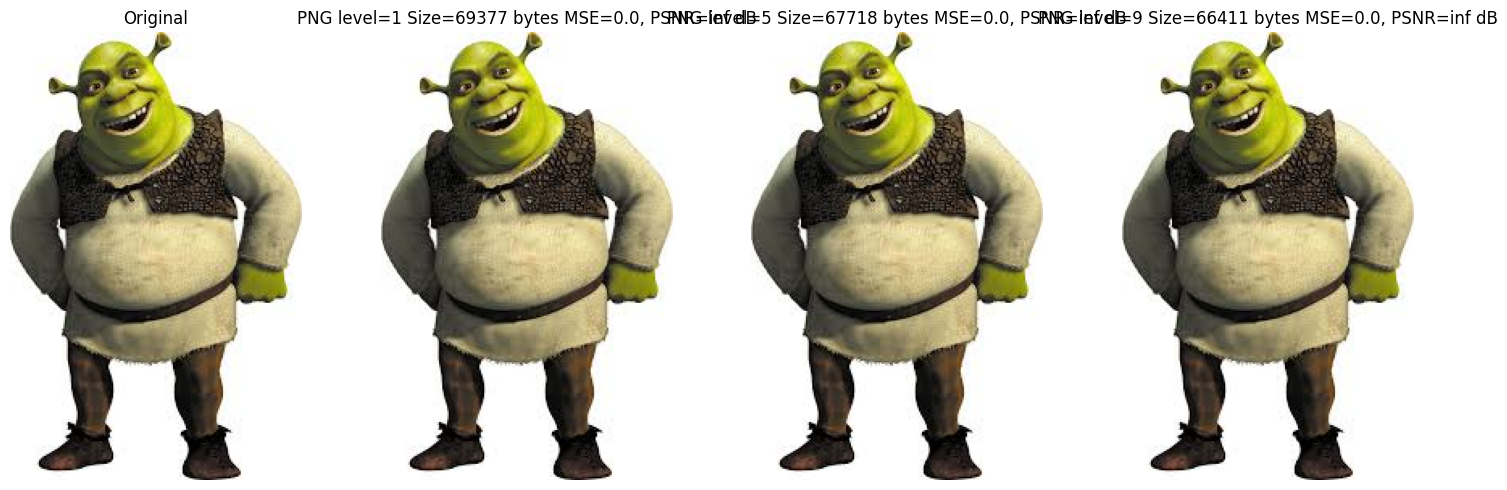

In [4]:
# PNG compression levels
png_levels = [1, 5, 9]
png_results = []

for level in png_levels:
    enc, dec = compress_png(img, compression_level=level)
    compressed_size = len(enc)
    mse = calculate_mse(img, dec)
    psnr = calculate_psnr(img, dec)
    png_results.append((level, compressed_size, mse, psnr, dec))

# Visualize the results
fig, axes = plt.subplots(1, len(png_levels) + 1, figsize=(15, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

for idx, (level, size, mse, psnr, dec_img) in enumerate(png_results, 1):
    axes[idx].imshow(cv2.cvtColor(dec_img, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f'PNG level={level} Size={size} bytes MSE={mse:.1f}, PSNR={psnr:.2f} dB')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## WEBP compression application

The WEBP format is a modern compression method and takes a quality parameter from 1–100. Values close to 100 correspond to lossless compression.


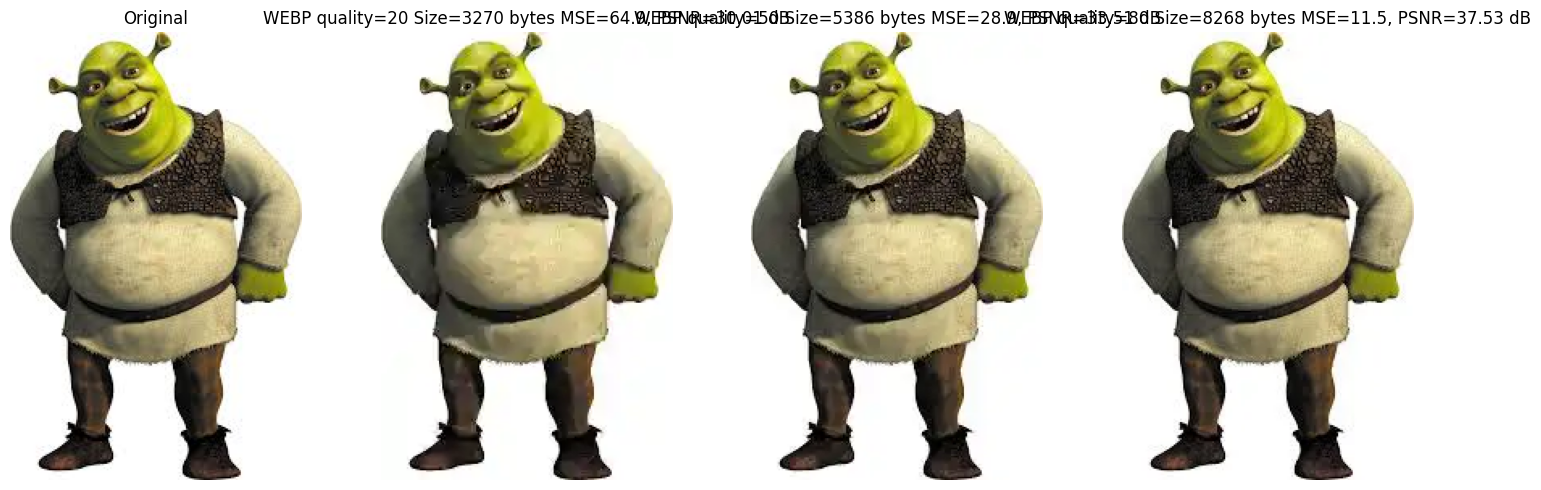

In [5]:
# WEBP quality values
webp_qualities = [20, 50, 80]
webp_results = []

for q in webp_qualities:
    enc, dec = compress_webp(img, quality=q)
    compressed_size = len(enc)
    mse = calculate_mse(img, dec)
    psnr = calculate_psnr(img, dec)
    webp_results.append((q, compressed_size, mse, psnr, dec))

# Visualize the results
fig, axes = plt.subplots(1, len(webp_qualities) + 1, figsize=(15, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

for idx, (q, size, mse, psnr, dec_img) in enumerate(webp_results, 1):
    axes[idx].imshow(cv2.cvtColor(dec_img, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f'WEBP quality={q} Size={size} bytes MSE={mse:.1f}, PSNR={psnr:.2f} dB')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Color quantization with K‑means

Color quantization is a technique that reduces the number of colors in an image to achieve compression. With the K‑means clustering algorithm, pixels with similar colors are assigned to the same cluster and each cluster is represented by the color of its centroid. This example uses the `MiniBatchKMeans` class from the `scikit‑learn` library.


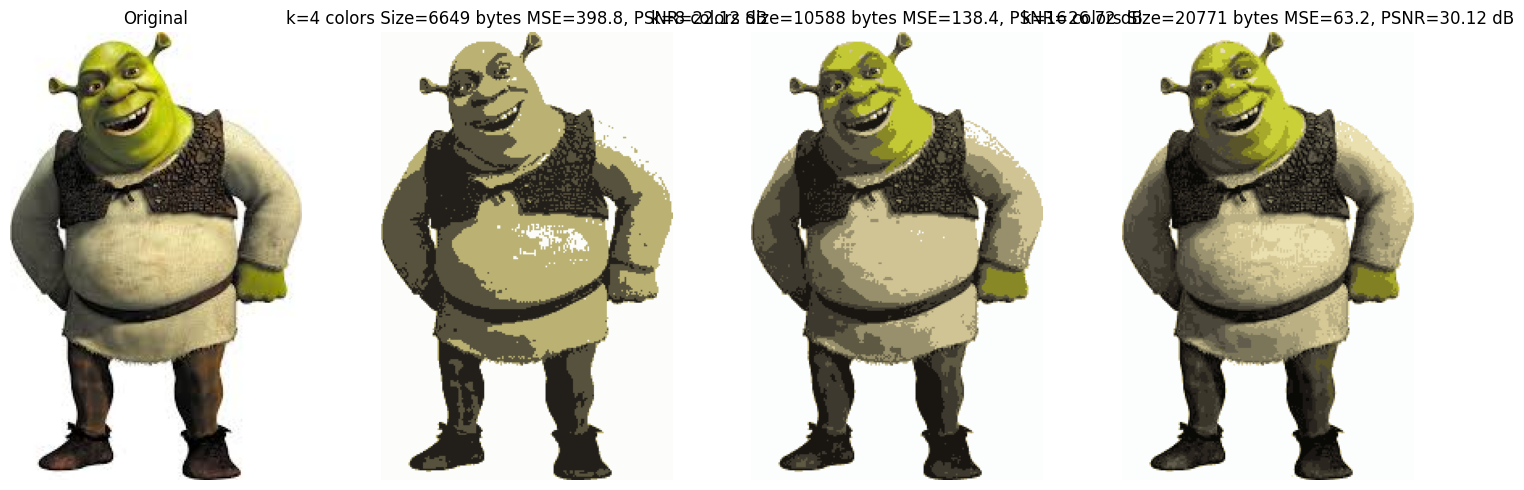

In [6]:
from sklearn.cluster import MiniBatchKMeans

# Color quantization function
def quantize_kmeans(image, k=8):
    h, w = image.shape[:2]
    # Convert to L*a*b* color space
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    # Flatten pixel data into a 2D matrix
    lab_data = lab.reshape((h * w, 3))
    # K-means clustering
    clt = MiniBatchKMeans(n_clusters=k)
    labels = clt.fit_predict(lab_data)
    quant = clt.cluster_centers_.astype('uint8')[labels]
    # Resize and convert to BGR color space
    quant = quant.reshape((h, w, 3))
    quant = cv2.cvtColor(quant, cv2.COLOR_LAB2BGR)
    return quant

# Quantization cluster numbers
cluster_nums = [4, 8, 16]
quant_results = []

for k in cluster_nums:
    quant_img = quantize_kmeans(img, k=k)
    # Save as PNG to roughly estimate the compressed file size
    enc, _ = compress_png(quant_img, compression_level=9)
    compressed_size = len(enc)
    mse = calculate_mse(img, quant_img)
    psnr = calculate_psnr(img, quant_img)
    quant_results.append((k, compressed_size, mse, psnr, quant_img))

# Visualize the results
fig, axes = plt.subplots(1, len(cluster_nums) + 1, figsize=(15, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

for idx, (k, size, mse, psnr, qimg) in enumerate(quant_results, 1):
    axes[idx].imshow(cv2.cvtColor(qimg, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f'k={k} colors Size={size} bytes MSE={mse:.1f}, PSNR={psnr:.2f} dB')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()